In [281]:
import numpy as np
import pandas as pd
import xgboost as xgb 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.base import clone
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)


## Prioject statement

Agricultural production forecasting plays a critical role in supporting food security, economic planning, and sustainable resource management. Accurate predictions of future crop production can enable governments, policymakers, farmers, and agricultural organizations to make informed decisions regarding production strategies, market planning, and supply chain management.

This project utilizes historical crop production data obtained from the Food and Agriculture Organization (FAO) to develop a machine learning model capable of predicting future crop production values that are not present in dataset. The FAO dataset provides comprehensive historical records of agricultural production across different countries and years, making it a valuable source for predictive analytics.

In order to evaluate model capabilities and define proper data flow the project specifically focuses on coffee production. Coffee production is influenced by numerous factors, including climate conditions, land use, technological advancements, and market demand. Although dataset contains only historical records related to Area harvested, Yield and total Production without any information on climate, environmental or political factors goal was to produce the model capable of identifying general trends and relationships within the historic data to generate relatively simple future production estimates in order to demonstrate capability of machine learning approaches to capture complex, non-linear patterns within time series data in food production context.

In addition to forecasting, this project also includes a clustering component aimed at grouping countries based on their agricultural production profiles. By analyzing the top crops produced in each country, clustering techniques such as K-Means allow the identification of natural groupings among countries with similar agricultural structures. This provides additional insight into global agricultural specialization patterns and helps in understanding similarities between countries in terms of crop production behavior.

Intended outcome of this project demonstrate the potential of data-driven forecasting and unsupervised learning in agriculture. The forecasting model supports strategic decision-making  (on example of coffee industry) while the clustering analysis enhances understanding of global agricultural production patterns. Furthermore, the methodology developed in this study can be extended to other crops or specific regions.

<b>Production [tons], Yield [kg/ha], Area [ha]</b> units used

In [282]:
data = pd.read_csv("Production_Crops_Livestock_E_All_Data.csv")
data2 = pd.read_csv("FAO_PIN_Merged.csv")

/tmp/ipykernel_917/344734770.py:1: DtypeWarning:

Columns (11,14,17,20,23,26,29,32,35,38,41,44,47,50,53,56,59,62,65,68,71,74,77,80,83,86,89,92,95,98,101,104,107,110,113,116,119,122,125,128,131,134,137,140,143,146,149,152,155,158,161,164,167,170,173,176,179,182,185,188,191,194,197,200) have mixed types. Specify dtype option on import or set low_memory=False.



In [283]:
# list for separating countries from regions
Areas = [
    'Africa',
    'Americas',
    'Asia',
    'Australia and New Zealand',
    'Central America',
    'Central Asia',
    'China, mainland',
    'Other non-specified areas',
    'Eastern Africa',
    'Eastern Asia',
    'Eastern Europe',
    'Europe',
    'European Union (27)',
    'Land Locked Developing Countries',
    'Least Developed Countries',
    'Low Income Food Deficit Countries',
    'Micronesia (Federated States of)',
    'Middle Africa',
    'Net Food Importing Developing Countries',
    'Northern Africa',
    'Northern America',
    'Northern Europe',
    'Oceania',
    'Polynesia',
    'Small Island Developing States',
    'South America',
    'South-eastern Asia',
    'Southern Africa',
    'Southern Asia',
    'Southern Europe',
    'Western Africa',
    'Western Asia',
    'Western Europe',
    'World'
]

In [284]:
print(data.head())

   Area Code Area Code (M49)         Area  Item Code Item Code (CPC)  \
0          2            '004  Afghanistan        221          '01371   
1          2            '004  Afghanistan        221          '01371   
2          2            '004  Afghanistan        221          '01371   
3          2            '004  Afghanistan        711          '01654   
4          2            '004  Afghanistan        711          '01654   

                                                Item  Element Code  \
0                                  Almonds, in shell          5312   
1                                  Almonds, in shell          5412   
2                                  Almonds, in shell          5510   
3  Anise, badian, coriander, cumin, caraway, fenn...          5312   
4  Anise, badian, coriander, cumin, caraway, fenn...          5412   

          Element   Unit  Y1961  ... Y2021N    Y2022  Y2022F Y2022N    Y2023  \
0  Area harvested     ha   0.00  ...    NaN 36462.00       A    Na

In [285]:
#PREFILTERING
data2 = data2[~data2["Country or Area"].isin(Areas)] # leaving only countries from dataset 2
Countries = list(data2["Country or Area"].unique()) # countries and columns filtered from the main data set
data = data[data["Area"].isin(Countries)] # leave just countries in main data

data = data.drop(columns=['Area Code (M49)', 'Area Code', 'Item Code (CPC)', 'Item Code', 'Element Code', 'Unit']) #unnecesary columns

years = list(range(1961, 2025))

for year in years:
    str_year = str(year)
    data = data.drop(columns="Y"+str_year+"F")
    data = data.drop(columns="Y"+str_year+"N")

year_cols = [col for col in data.columns if col.startswith("Y")]

data = data.melt( 
    id_vars=["Area", "Item", "Element"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
) # datased is converted from years in columns to year in rows and all values are in one column

data["Year"] = (
    data["Year"]
    .str.replace("Y", "")
    .astype(int)
)

wanted_elements = [
    "Production",
    "Area harvested",
    "Yield"
]

data = data[
    data["Element"].isin(wanted_elements)
]

# CONVERT LONG → WIDE
data = (
    data.pivot_table(
        index=[
            "Area",
            "Year",
            "Item"
        ],
        columns="Element",
        values="Value",
        aggfunc="mean"
    )
    .reset_index()
)

data.columns.name = None

# data.dropna(inplace=True)

data.head(10)

# data.to_csv("prefilt_data.csv", index=False)

,Area,Year,Item,Area harvested,Production,Yield
0,Afghanistan,1961,"Almonds, in shell",0.00,0.00,NaN
1,Afghanistan,1961,Apples,2220.00,15100.00,6801.80
2,Afghanistan,1961,Apricots,4820.00,32000.00,6639.00
3,Afghanistan,1961,Barley,350000.00,378000.00,1080.00
4,Afghanistan,1961,"Beef and Buffalo Meat, primary",NaN,43000.00,NaN
5,Afghanistan,1961,Butter and Ghee,NaN,11104.00,NaN
6,Afghanistan,1961,Butter and ghee of sheep milk,NaN,4104.00,NaN
7,Afghanistan,1961,Butter of cow milk,NaN,7000.00,NaN
8,Afghanistan,1961,Cantaloupes and other melons,3300.00,15700.00,4757.60
9,Afghanistan,1961,"Cattle fat, unrendered",NaN,1054.72,NaN


In [286]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix["Production"].sort_values(ascending=False) 

# Area harvested is most correlated with production
# PRODUCTION = YIELD * AREA 
# Idea is to remove production information and predict yield and area and then calculate predicted production 

Production       1.00
Area harvested   0.59
Year             0.03
Yield            0.02
Name: Production, dtype: float64

In [287]:
# "data" are derived from main data line

df_rank = data.groupby(
    ["Area", "Item"]
)["Production"].mean().reset_index()

df_rank["rank"] = df_rank.groupby(
    "Area"
)["Production"].rank(
    ascending=False,
    method="first"
)

# select top 5
df_top5 = df_rank[df_rank["rank"] <= 5]

data_top5 = data.merge(
    df_top5[["Area", "Item"]],
    on=["Area", "Item"],
    how="inner"
)


In [288]:
data_co = data[data["Item"].isin(["Coffee, green", "Cocoa beans"])] #coffee and cocoa data together

In [289]:
# DATASETS FOR ANALYSIS - everything, coffe and cocoa, top 5 items in each country
# print(data)
# print(data_co)
# print(data_top5)

# data.to_csv("data.csv", index=False)
# data.to_csv("data_co.csv", index=False)
# data.to_csv("data_top5.csv", index=False)

In [290]:
# definiton of coffee and cocoa datasets

data_cof = data_co[data_co["Item"] == "Coffee, green"]
data_coc = data_co[data_co["Item"] == "Cocoa beans"]
data_cof = data_cof.drop(columns='Item')
data_coc = data_coc.drop(columns='Item')


In [291]:
data_cof = data_co[data_co["Item"] == "Coffee, green"]
data_cof = data_cof.drop(columns='Item')

COFFEE

ENGINEERING FEATURES

In [292]:
# chosen_prod = coffee

df = data_cof.copy() #copy data to df for processing
df = data_cof.drop(columns='Production') # drop production
df = df[df["Year"] <= 2024]
df = df.sort_values(["Area", "Year"])

def add_lags(df, cols, lags=[1,2,3]): #function for engineering lag features

    df = df.copy()

    for col in cols:

        for lag in lags:

            df[f"{col}_lag{lag}"] = (
                df
                .groupby(["Area"])[col]
                .shift(lag)
            )

    return df 


def add_rolling(df, col): # function for engineering rolling mean features

    df = df.copy()

    # for col in cols: # GPT not so smart ha

    df[f"{col}_roll3"] = (
        df
        .groupby(["Area"])[col]
        .transform(
            lambda x:
            x.shift(1)
                .rolling(3,min_periods=1)
                .mean()
        )
    )

    df[f"{col}_roll5"] = (
        df
        .groupby(["Area"])[col]
        .transform(
            lambda x:
            x.shift(1)
                .rolling(5,min_periods=1)
                .mean()
        )
    )

    return df


def add_growth(df, cols): # function for engineering growth rate features

    df = df.copy()

    for col in cols:

        df[f"{col}_growth"] = (
            df
            .groupby(["Area"])[col]
            .pct_change()
        )

    return df


def add_growth_5y(df, cols):

    df = df.copy()

    for col in cols:

        prev = (
            df.groupby(["Area"])[col]
              .shift(1)
        )

        prev5 = (
            df.groupby(["Area"])[col]
              .shift(5)
        )

        df[f"{col}_growth5y"] = (
            (prev - prev5) / prev5
        )

    return df

base_cols = ["Yield","Area harvested"]

# apply feature funcs
df = add_lags(df, base_cols)
df = add_rolling(df, base_cols[0])
df = add_rolling(df, base_cols[1])
df = add_growth(df, base_cols)
df = add_growth_5y(df, base_cols)


/tmp/ipykernel_917/2860215581.py:65: FutureWarning:

The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

/tmp/ipykernel_917/2860215581.py:65: FutureWarning:

The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



In [293]:
# df input to model training and testing
df

,Area,Year,Area harvested,Yield,Yield_lag1,Yield_lag2,Yield_lag3,Area harvested_lag1,Area harvested_lag2,Area harvested_lag3,Yield_roll3,Yield_roll5,Area harvested_roll3,Area harvested_roll5,Yield_growth,Area harvested_growth,Yield_growth5y,Area harvested_growth5y
20451,Angola,1961,350000.00,481.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20534,Angola,1962,500000.00,370.00,481.70,NaN,NaN,350000.00,NaN,NaN,481.70,481.70,350000.00,350000.00,-0.23,0.43,NaN,NaN
20617,Angola,1963,500000.00,336.60,370.00,481.70,NaN,500000.00,350000.00,NaN,425.85,425.85,425000.00,425000.00,-0.09,0.00,NaN,NaN
20700,Angola,1964,500000.00,396.40,336.60,370.00,481.70,500000.00,500000.00,350000.00,396.10,396.10,450000.00,450000.00,0.18,0.00,NaN,NaN
20783,Angola,1965,500000.00,410.00,396.40,336.60,370.00,500000.00,500000.00,500000.00,367.67,396.18,500000.00,462500.00,0.03,0.00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122597,Zimbabwe,2020,573.00,1010.50,979.70,1086.00,1095.50,542.00,453.00,498.00,1053.73,1076.18,497.67,515.00,0.03,0.06,-0.12,0.21
1122742,Zimbabwe,2021,676.00,899.40,1010.50,979.70,1086.00,573.00,542.00,453.00,1025.40,1055.36,522.67,539.80,-0.11,0.18,-0.09,-0.09
1122887,Zimbabwe,2022,681.00,1000.00,899.40,1010.50,979.70,676.00,573.00,542.00,963.20,1014.22,597.00,548.40,0.11,0.01,-0.18,0.36
1123032,Zimbabwe,2023,685.00,971.50,1000.00,899.40,1010.50,681.00,676.00,573.00,969.97,995.12,643.33,585.00,-0.03,0.01,-0.08,0.50


In [294]:
categorical_features = ["Area"]

numeric_features = [
    "Year",

    "Yield_lag1",
    "Yield_lag2",
    "Yield_lag3",

    "Area harvested_lag1",
    "Area harvested_lag2",
    "Area harvested_lag3",

    "Yield_roll3",
    "Yield_roll5",

    "Area harvested_roll3",
    "Area harvested_roll5",

    "Yield_growth",
    "Area harvested_growth",
    "Yield_growth5y",
    "Area harvested_growth5y"
]

TRANSFORMATION PIPELINE

In [295]:
# pipeline architecture

preprocessor = ColumnTransformer(
    transformers=[
        ("cat",
         Pipeline([
             ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
             ("ohe", OneHotEncoder(handle_unknown="ignore"))
         ]),
         categorical_features),

        ("num",
         Pipeline([
             ("imputer", SimpleImputer(strategy="median")),
             ("standardize", MinMaxScaler(feature_range=(-1, 1)))
         ]),
         numeric_features)
    ]
)

CHOICE OF MODELS AND DEFINING ERROR MEASURES

In [296]:
#choice of models with initial hyperparameters, will be tuned later

models = {

    "LinearRegression":

        LinearRegression(),

    "DecisionTree":

        DecisionTreeRegressor(
            max_depth=8,
            random_state=42
        ),

    "XGBoost":

        XGBRegressor(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )
}

In [297]:
#metrics for evaluation
def rmse(y_true,y_pred):

    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

def mape(y_true,y_pred):

    y_true = np.array(y_true)

    y_pred = np.array(y_pred)

    mask = y_true != 0

    return (
        np.abs(
            (y_true[mask]-y_pred[mask])
            /
            y_true[mask]
        ).mean()
        *100
    )

TRAINING

In [298]:
# training function

def train_models(df,target):

    X = df[
        categorical_features +
        numeric_features
    ]

    y = df[target]

    tscv = TimeSeriesSplit( #creates dataset split object on which n-fold cross validation is performed
        n_splits=5
    )

    fitted = {}

    results = []

    for name, model in models.items():

        pipe = Pipeline([

            ("prep",preprocessor),

            ("model", clone(model))

        ])

        maes = []
        rmses = []
        mapes = []

        for train_idx,test_idx in tscv.split(X):

            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            pipe.fit(
                X_train,
                y_train
            )

            preds = pipe.predict(
                X_test
            )

            maes.append(
                mean_absolute_error(
                    y_test,
                    preds
                )
            )

            rmses.append(
                rmse(
                    y_test,
                    preds
                )
            )

            mapes.append(
                mape(
                    y_test,
                    preds
                )
            )

        results.append({

            "Target":target,

            "Model":name,

            "MAE":np.mean(maes),

            "RMSE":np.mean(rmses),

            "MAPE":np.mean(mapes)

        })

        pipe.fit(X,y)

        fitted[name] = pipe

    return fitted,pd.DataFrame(results)

In [299]:
# df
df = df.replace([np.inf, -np.inf], np.nan) # there was a bug with infinite values 
# df = df.dropna()

tseries_split = TimeSeriesSplit(n_splits=5)

df["Area"] = df["Area"].astype("category")

area_df = df[
    df["Area harvested"].notna()
].copy()

yield_df = df[
    df["Yield"].notna()
].copy()

Xx = area_df[
    categorical_features +
    numeric_features
]

yy = area_df["Area harvested"]

for train_idx,test_idx in tseries_split.split(Xx): # repetitive but for thepurpose of randimized search

    X_train = Xx.iloc[train_idx]
    X_test = Xx.iloc[test_idx]

    y_train = yy.iloc[train_idx]
    y_test = yy.iloc[test_idx]



In [300]:
from sklearn.model_selection import RandomizedSearchCV

rs_param_grid = {
    'max_depth': list((range(3,8))),
    'alpha': [0,0.001, 0.01,0.1,1],
    'subsample': [0.5,0.75,1],
    'learning_rate': np.linspace(0.01,0.5, 10),
    'n_estimators': [100, 250, 500, 700]
    }

xgb_clf = xgb.XGBRegressor(enable_categorical=True, eval_metric='error', random_state=123)

# already performed and commented out to save execution time

# xgb_rs = RandomizedSearchCV(estimator=xgb_clf,param_distributions=rs_param_grid,
#                                 cv=3, n_iter=5, verbose=2, random_state=123)
# xgb_rs.fit(X_train, y_train) 

# print("Best parameters found: ", xgb_rs.best_params_)
# print("Best accuracy found: ", xgb_rs.best_score_)

In [301]:
#choice off models with initial hyperparameters, will be tuned later

models = {

    "LinearRegression":

        LinearRegression(),

    "DecisionTree":

        DecisionTreeRegressor(
            max_depth=8,
            random_state=42
        ),

    "XGBoost": #Optimal hyperparameters found by RandomizedSearchCV for XGBoost model

        XGBRegressor(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.445,
            subsample=0.5,
            colsample_bytree=0.8,
            alpha=0.001,
            random_state=42
        )
}

In [302]:
#area and yield model training

area_models, area_scores = train_models(
    area_df,
    "Area harvested"
)

yield_models, yield_scores = train_models(
    yield_df,
    "Yield"
)

# print("Yield target")
# print(yield_df["Yield"].head())

# print("Area target")
# print(area_df["Area harvested"].head())

print("Yield mean:", yield_df["Yield"].mean())
print("Area mean:", area_df["Area harvested"].mean())

Yield mean: 633.7442303792334
Area mean: 132594.09735744089


In [303]:
# print(id(yield_models["XGBoost"].named_steps["model"]))
# print(id(area_models["XGBoost"].named_steps["model"]))

In [304]:
#compare scores

all_scores = pd.concat(
    [
        yield_scores,
        area_scores
    ]
)

print(
    all_scores
    .sort_values(
        ["Target","MAPE"]
    )
)

           Target             Model                  MAE                 RMSE  \
1  Area harvested      DecisionTree             12639.98             31554.33   
2  Area harvested           XGBoost             11498.73             26270.20   
0  Area harvested  LinearRegression 39165307673695664.00 40601339541549760.00   
1           Yield      DecisionTree                73.10               253.93   
2           Yield           XGBoost                68.95               264.76   
0           Yield  LinearRegression    10520273950827.36    10701853756966.40   

                  MAPE  
1               275.54  
2              1565.57  
0 76325663329979792.00  
1                15.18  
2                16.11  
0     2584653847320.99  


FORECASTS 2025, 2026

In [305]:
yield_model = yield_models["XGBoost"] # choice was on XGBoost based on error scores and results matching real trends better
area_model = area_models["XGBoost"]

In [306]:
#forecast function
def forecast_country(
    hist,
    yield_model,
    area_model,
    years=[2025,2026]
):

    hist = hist.copy()

    forecasts = []

    for year in years:

        row = {}

        row["Area"] = hist.iloc[-1]["Area"]
        # row["Item"] = hist.iloc[-1]["Item"]

        row["Year"] = year

        for col in [
            # "Production",
            "Yield",
            "Area harvested"
        ]:

            row[f"{col}_lag1"] = hist[col].iloc[-1]

            row[f"{col}_lag2"] = (
                hist[col].iloc[-2]
            )

            row[f"{col}_lag3"] = (
                hist[col].iloc[-3]
            )

            row[f"{col}_roll3"] = (
                hist[col]
                .tail(3)
                .mean()
            )

            row[f"{col}_roll5"] = (
                hist[col]
                .tail(5)
                .mean()
            )

            row[f"{col}_growth"] = (
                hist[col]
                .pct_change()
                .iloc[-1]
            )

            row[f"{col}_growth5y"] = (
                hist[col]
                .pct_change(periods=5)
                .iloc[-1]
            )

        X_pred = pd.DataFrame([row])
        # print("blalableala")
        # print(X_pred)
        # print("blalableala")
        
        yield_pred = (
            yield_model
            .predict(X_pred)[0]
        )

        area_pred = (
            area_model
            .predict(X_pred)[0]
        )
        # print("khmkhmkhm")
        # production_pred = (
        #     yield_pred *
        #     area_pred
        # )
        # print(yield_pred)
        # print(area_pred)
        row["Yield"] = yield_pred
        row["Area harvested"] = area_pred
        # row["Production"] = production_pred

        forecasts.append(row)

        hist = pd.concat(
            [
                hist,
                pd.DataFrame([row])
            ],
            ignore_index=True
        )

    return pd.DataFrame(
        forecasts
    )

In [307]:
df["Area"] = df["Area"].astype("object")

In [308]:
#forecasts for all countries

predictions = []
df = df.dropna() # from original df wich is used to fetch historic data used by forecast_country()

for (country), group in df.groupby(
    ["Area"]
):

    fc = forecast_country(
        group.sort_values("Year"),
        yield_model,
        area_model
    )

    predictions.append(fc)

predictions = pd.concat(
    predictions,
    ignore_index=True
)

predictions["Production"] = (predictions["Yield"] * predictions["Area harvested"])/1000

In [309]:
print(predictions[(predictions["Area"] == "Brazil")])

     Area  Year  Yield_lag1  Yield_lag2  Yield_lag3  Yield_roll3  Yield_roll5  \
8  Brazil  2025     1742.70     1757.50     1702.60      1734.27      1756.80   
9  Brazil  2026     1752.83     1742.70     1757.50      1751.01      1716.97   

   Yield_growth  Yield_growth5y  Area harvested_lag1  Area harvested_lag2  \
8         -0.01            0.06           1943977.00           1905239.00   
9          0.01           -0.10           1931214.50           1943977.00   

   Area harvested_lag3  Area harvested_roll3  Area harvested_roll5  \
8           1867392.00            1905536.00            1889509.00   
9           1905239.00            1926810.17            1896066.10   

   Area harvested_growth  Area harvested_growth5y   Yield  Area harvested  \
8                   0.02                     0.07 1752.83      1931214.50   
9                  -0.01                     0.02 1759.92      1899014.75   

   Production  
8  3385092.25  
9  3342123.00  


In [310]:
YP2025 = predictions[predictions["Year"] == 2025]
YP2025 = YP2025[["Area","Production", "Area harvested", "Yield"]]
YP2025 = YP2025.sort_values("Production", ascending=False)  
YP2025

,Area,Production,Area harvested,Yield
8,Brazil,3385092.25,1931214.50,1752.83
154,Viet Nam,2063997.25,688288.88,2998.74
24,Colombia,1122956.88,855805.62,1312.16
72,Indonesia,843164.88,1273792.25,661.93
50,Ethiopia,629187.56,886322.31,709.89
...,...,...,...,...
120,Saint Vincent and the Grenadines,-566.13,-1725.66,328.07
64,Guyana,-738.62,-909.07,812.50
140,Tonga,-771.69,-592.18,1303.13
40,Dominica,-1100.91,-1241.65,886.66


In [311]:
YP2024 = predictions[predictions["Year"] == 2024]
YP2024 = YP2024[["Area","Production", "Area harvested", "Yield"]]
YP2024 = YP2024.sort_values("Production", ascending=False)  
YP2024

,Area,Production,Area harvested,Yield


In [312]:
YP2026 = predictions[predictions["Year"] == 2026]
YP2026 = YP2026[["Area","Production", "Area harvested", "Yield"]]
YP2026 = YP2026.sort_values("Production", ascending=False)  
YP2026

,Area,Production,Area harvested,Yield
9,Brazil,3342123.00,1899014.75,1759.92
155,Viet Nam,2250305.75,672644.94,3345.46
25,Colombia,1428109.62,900486.31,1585.93
73,Indonesia,856354.94,1289909.12,663.89
51,Ethiopia,656779.81,865613.62,758.74
...,...,...,...,...
123,Samoa,-1263.43,-3622.66,348.76
41,Dominica,-1438.92,-1829.95,786.32
65,Guyana,-1507.04,-2067.44,728.94
53,Fiji,-1523.46,-1793.04,849.65


In [313]:
data_cof[data_cof["Year"] == 2024].sort_values("Production", ascending=False)
Y2024 = data_cof[data_cof["Year"] == 2024].sort_values("Production", ascending=False)
Y2024 = Y2024[["Area","Production", "Area harvested", "Yield"]]
Y2024
# Y2024[Y2024["Area"] == "New Caledonia"]
# Y2024[Y2024["Area"] == "Nicaragua"]
# data_cof[data_cof["Area"] == "Nicaragua"].tail(10) 

,Area,Production,Area harvested,Yield
128642,Brazil,3387724.00,1943977.00,1742.70
1103275,Viet Nam,2015289.00,678569.00,2969.90
231488,Colombia,839846.69,837685.00,1002.60
482877,Indonesia,807578.00,1269354.00,636.20
351120,Ethiopia,575696.18,862943.00,667.10
...,...,...,...,...
881341,Samoa,11.79,39.00,300.20
884563,Sao Tome and Principe,7.27,131.00,55.70
958532,Suriname,6.22,292.00,21.30
722701,New Caledonia,1.01,7.00,138.20


GEO VISUALISATION OF RESULTS

In [314]:
df_2024 = Y2024.rename(columns={"Production": "2024"})
df_2025 = YP2025.rename(columns={"Production": "2025"})

df_2024 = df_2024.drop(columns=["Area harvested", "Yield"])
df_2025 = df_2025.drop(columns=["Area harvested", "Yield"])

merged = pd.merge(df_2024, df_2025, on="Area", suffixes=("_2024", "_2025"))

num_cols = merged.select_dtypes(include="number").columns
merged[num_cols] = merged[num_cols].clip(lower=0)

merged["Increase"] = (merged["2025"] - merged["2024"]) / merged["2024"] * 100
pd.set_option('display.float_format', '{:.2f}'.format)
merged = merged.round(2)
std_scaler = StandardScaler()
# merged[['Increase']] = std_scaler.fit_transform(merged[['Increase']])
merged

upper = merged["Increase"].quantile(0.99)

merged["Increase_clipped"] = merged["Increase"].clip(upper=upper)

merged["abs_change"] = merged["2025"] - merged["2024"]

total_change = merged["abs_change"].abs().sum()

merged["global_impact"] = merged["abs_change"] / total_change *100

In [ ]:
import plotly.express as px

Increase = merged[["Area","global_impact"]]

#not relevant different color scale used 

# fig = px.choropleth(
#     Increase,
#     locations="Area",
#     locationmode="country names",
#     color="global_impact",
#     color_continuous_scale="Viridis",
#     range_color=(merged["global_impact"].min(), merged["global_impact"].max()),
#     title="Global Impact of Change from 2024 to 2025 (%)"
# )

# fig.show()

In [316]:
# Increase2 = merged[["Area","Increase"]]

# fig = px.choropleth(
#     Increase2,
#     locations="Area",
#     locationmode="country names",
#     color="Increase",
#     color_continuous_scale="Viridis",
#     range_color=(
#         Increase2["Increase"].quantile(0.1),
#         Increase2["Increase"].quantile(0.80)
#     ),
#     title="Production Increase from 2024 to 2025 (%)"
# )

# fig.show()

In [317]:
pos = merged.copy()
neg = merged.copy()

pos["Increase_pos"] = pos["Increase"].where(pos["Increase"] > 0)
neg["Increase_neg"] = neg["Increase"].where(neg["Increase"] < 0)
neg["Increase_neg"] = neg["Increase_neg"].abs()

pos.dropna(inplace=True, subset=["Increase_pos"])
neg.dropna(inplace=True, subset=["Increase_neg"])

pos_clip = pos["Increase_pos"].quantile(0.50)
neg_clip = neg["Increase_neg"].quantile(0.50)

print(pos_clip)
print(neg_clip)

pos["Increase_pos_clipped"] = pos["Increase_pos"].clip(upper=pos_clip)
neg["Increase_neg_clipped"] = neg["Increase_neg"].clip(upper=neg_clip)

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Choropleth(
    locations=pos["Area"],
    locationmode="country names",
    z=pos["Increase_pos"],
    colorscale="Greens",
    zmin=0,
    zmax=pos_clip,
    showscale=True,
    colorbar_title="Increase (+)"
))

fig.add_trace(go.Choropleth(
    locations=neg["Area"],
    locationmode="country names",
    z=neg["Increase_neg"],
    colorscale="Reds",
    zmin=0,
    zmax=neg_clip,
    showscale=True,
    colorbar_title="Decrease (-)"
))

fig.update_layout(
    title="Production Change 2024-2025 (%) (Increase vs Decrease)",
    geo=dict(showframe=False, showcoastlines=True)
)

fig.show()

9.985
18.84


In [318]:
# impact is abs change in one country production compared to total global change

pos_impact = merged.copy()
neg_impact = merged.copy()

pos_impact["Increase_impact_pos"] = pos_impact["global_impact"].where(pos_impact["global_impact"] > 0)
neg_impact["Increase_impact_neg"] = neg_impact["global_impact"].where(neg_impact["global_impact"] < 0)
neg_impact["Increase_impact_neg"] = neg_impact["Increase_impact_neg"].abs()

pos_impact.dropna(inplace=True, subset=["Increase_impact_pos"])
neg_impact.dropna(inplace=True, subset=["Increase_impact_neg"])

pos_clip = pos_impact["Increase_impact_pos"].quantile(0.90)
neg_clip = neg_impact["Increase_impact_neg"].quantile(0.90)

print(pos_clip)
print(neg_clip)

pos_impact["Increase_pos_clipped"] = pos_impact["Increase_impact_pos"].clip(upper=pos_clip)
neg_impact["Increase_neg_clipped"] = neg_impact["Increase_impact_neg"].clip(upper=neg_clip)

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Choropleth(
    locations=pos_impact["Area"],
    locationmode="country names",
    z=pos_impact["Increase_impact_pos"],
    colorscale="Greens",
    zmin=0,
    zmax=pos_clip,
    showscale=True,
    colorbar_title="Increase (+)"
))

fig.add_trace(go.Choropleth(
    locations=neg_impact["Area"],
    locationmode="country names",
    z=neg_impact["Increase_impact_neg"],
    colorscale="Reds",
    zmin=0,
    zmax=neg_clip,
    showscale=True,
    colorbar_title="Decrease (-)"
))

fig.update_layout(
    title="Global Impact Change % (country production compared to total global change)",
    geo=dict(showframe=False, showcoastlines=True)
)

fig.show()

5.705099045067977
1.1723736539103256


Prediction for 2025 is that Brazil's production decreases while Colombia's prodution boom; similar to our results (but, our results are based on historical data only while climate and weather foctors also have huge impact).

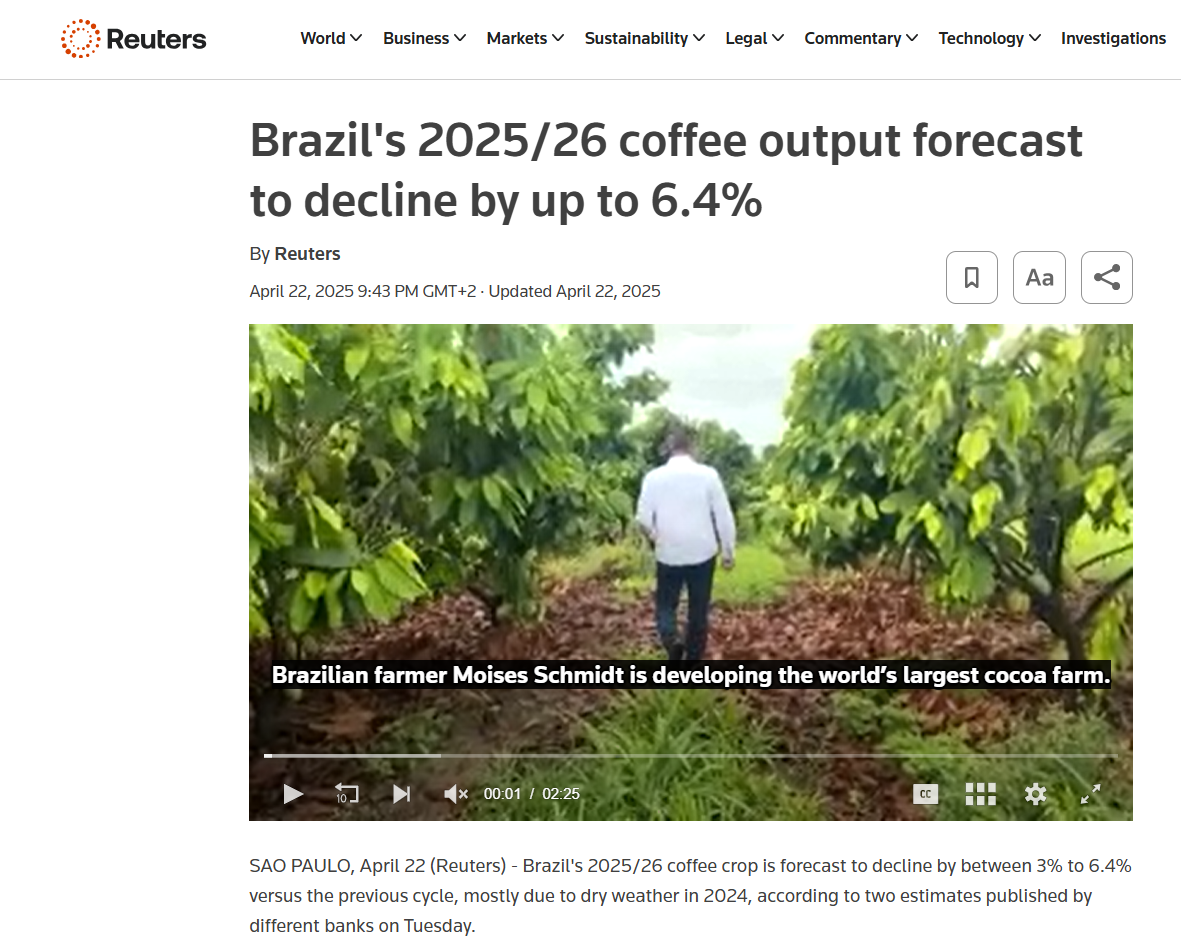

In [319]:
from IPython.display import Image, display

display(Image(filename="figs/Screenshot 2026-06-01 145049.png"))

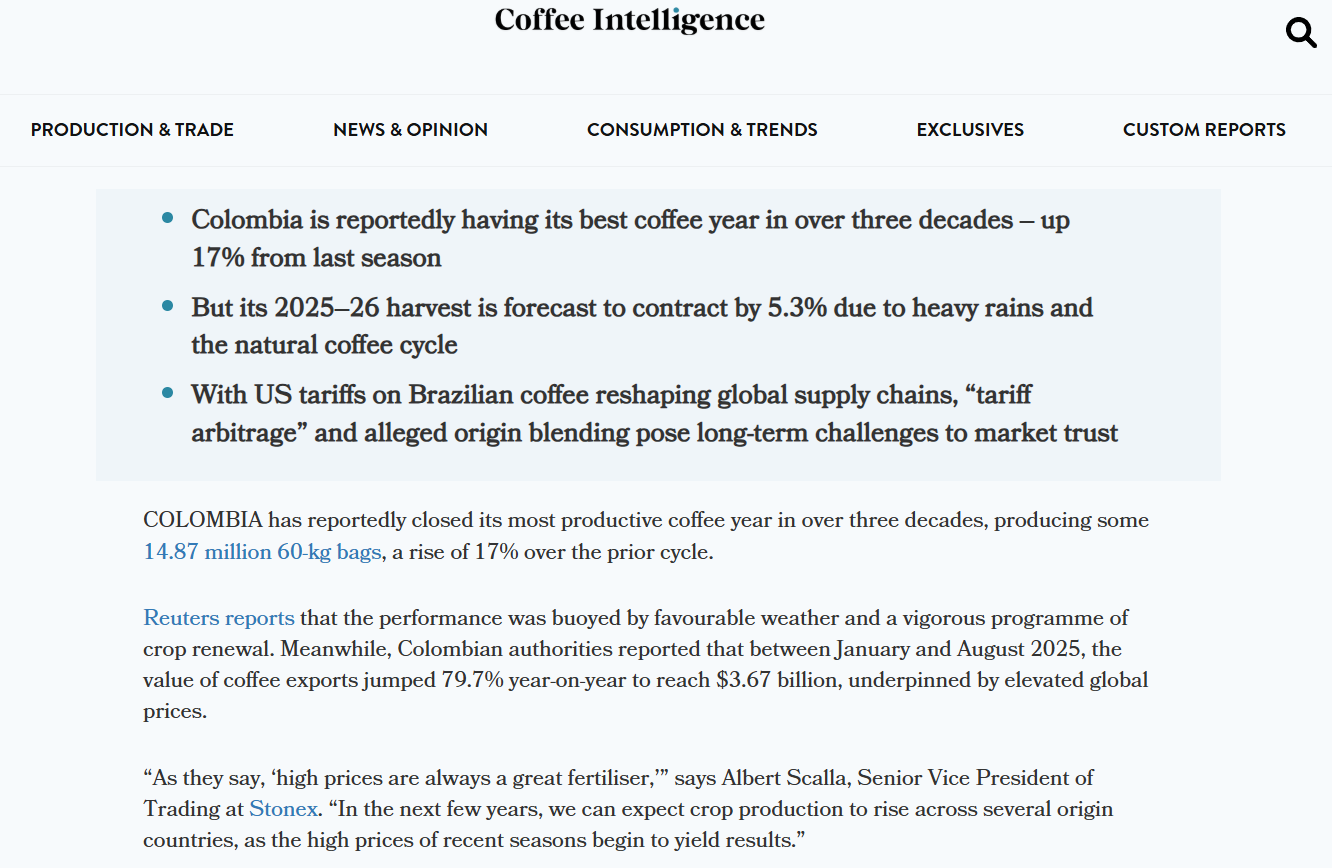

In [320]:
display(Image(filename="figs/Screenshot 2026-06-01 145544.png"))

# Clustering: country crop production profiles

Following the 5-step process from the clustering slides:
1. Transformation (build the country x crop matrix, convert to relative share, standardize)
2. Dissimilarity measure (Euclidean)
3. Algorithm choice (K-means)
4. Cluster validation (Elbow + Silhouette), run on the full last-20-years window and on each 5-year sub-period
5. Labelling, profiling, and tracking cluster changes across periods

This section reads the raw FAOSTAT file fresh and does not modify anything in the pipeline above.

## Step 1: Transformation

In [47]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

### 1a. Crops-only production data (no livestock)

FAOSTAT's `Item Code (CPC)` classifies items: codes starting with `01` are crops, codes starting with `02` are live animals / animal products. We filter on that instead of a hand-built exclude list.

In [98]:
raw = pd.read_csv("Production_Crops_Livestock_E_All_Data.csv")


# harmonize country name mismatches between the two source files
import re

def fix_turkey(name):
    return "Turkey" if re.match(r"^T.rkiye$", name) else name

raw["Area"] = raw["Area"].apply(fix_turkey)
Countries = [fix_turkey(c) for c in Countries]

raw = raw[raw["Area"].isin(Countries)]      # reuse the country list defined earlier in the notebook
raw = raw[raw["Element"] == "Production"]   # production values only

import re

def cpc_prefix(code):
    # FAOSTAT bulk files often store this as text with a leading apostrophe (e.g. '01111)
    # to preserve the leading zero in Excel -> strip everything that is not a digit first.
    s = re.sub(r"[^0-9]", "", str(code))
    if not s:
        return "NA"
    return s.zfill(5)[:2]

raw["cpc_prefix"] = raw["Item Code (CPC)"].apply(cpc_prefix)

# sanity check before trusting the filter: should be dominated by '01' (crops) and '02' (livestock)
print(raw["cpc_prefix"].value_counts())

/var/folders/00/r7q3042912d7dkbd9jqylzjc0000gn/T/ipykernel_91704/4028058113.py:1: DtypeWarning:

Columns (11,14,17,20,23,26,29,32,35,38,41,44,47,50,53,56,59,62,65,68,71,74,77,80,83,86,89,92,95,98,101,104,107,110,113,116,119,122,125,128,131,134,137,140,143,146,149,152,155,158,161,164,167,170,173,176,179,182,185,188,191,194,197,200) have mixed types. Specify dtype option on import or set low_memory=False.



cpc_prefix
01    12805
21     3885
02     2034
00     1753
22     1257
23      273
24      266
17      136
26       30
03        4
Name: count, dtype: int64


In [99]:
crops = raw[raw["cpc_prefix"] == "01"].copy()

excluded_items = sorted(raw.loc[raw["cpc_prefix"] != "01", "Item"].unique())
print(f"{len(excluded_items)} non-crop items excluded, e.g.:")
print(excluded_items[:20])

included_items = sorted(crops["Item"].unique())
print(f"\n{len(included_items)} crop items included")

105 non-crop items excluded, e.g.:
['Balata, gutta-percha, guayule, chicle and similar natural gums in primary forms or in plates, sheets or strip', 'Barley', 'Beer of barley, malted', 'Beeswax', 'Buffalo fat, unrendered', 'Butter and ghee of sheep milk', 'Butter of buffalo milk', 'Butter of cow milk', 'Buttermilk, dry', 'Cattle fat, unrendered', 'Cheese from milk of buffalo, fresh or processed', 'Cheese from milk of goats, fresh or processed', 'Cheese from milk of sheep, fresh or processed', 'Cheese from skimmed cow milk', 'Cheese from whole cow milk', 'Coconut oil', 'Cotton seed', 'Cottonseed oil', 'Cream, fresh', 'Edible offal of buffalo, fresh, chilled or frozen']

175 crop items included


### 1b. Restrict to the last 20 years and reshape long

Using 2005-2024 as "the last 20 years" (the data goes up to Y2024).

In [100]:
year_cols_clustering = [f"Y{y}" for y in range(2005, 2025)]
year_cols_clustering = [c for c in year_cols_clustering if c in crops.columns]  # drop the F/N flag columns automatically

crops_long = crops.melt(
    id_vars=["Area", "Item"],
    value_vars=year_cols_clustering,
    var_name="YearCol",
    value_name="Production"
)

crops_long["Year"] = crops_long["YearCol"].str.replace("Y", "", regex=False).astype(int)
crops_long = crops_long.drop(columns="YearCol")
crops_long["Production"] = crops_long["Production"].fillna(0)

crops_long.head()

,Area,Item,Production,Year
0,Afghanistan,"Almonds, in shell",15630.00,2005
1,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",10000.00,2005
2,Afghanistan,Apples,20239.34,2005
3,Afghanistan,Apricots,49623.01,2005
4,Afghanistan,"Beans, dry",0.00,2005


### 1c. Define the periods: full 20y + four 5y windows

In [101]:
periods = {
    "2005-2024": range(2005, 2025),
    "2005-2009": range(2005, 2010),
    "2010-2014": range(2010, 2015),
    "2015-2019": range(2015, 2020),
    "2020-2024": range(2020, 2025),
}

five_year_periods = [name for name in periods if name != "2005-2024"]

top 50 crops

In [102]:
top_n = 50

global_totals = crops_long.groupby("Item")["Production"].sum().sort_values(ascending=False)
top_items = global_totals.head(top_n).index.tolist()

print(f"Top {top_n} crops by total global production (2005-2024):")
print(top_items)

crops_long_top = crops_long[crops_long["Item"].isin(top_items)].copy()

Top 50 crops by total global production (2005-2024):
['Cereals, primary', 'Sugar Crops Primary', 'Sugar cane', 'Vegetables Primary', 'Roots and Tubers, Total', 'Fruit Primary', 'Milk, Total', 'Oilcrops, Cake Equivalent', 'Potatoes', 'Meat, Total', 'Oil palm fruit', 'Cassava, fresh', 'Other vegetables, fresh n.e.c.', 'Sugar beet', 'Oilcrops, Oil Equivalent', 'Tomatoes', 'Citrus Fruit, Total', 'Bananas', 'Meat, Poultry', 'Watermelons', 'Sweet potatoes', 'Onions and shallots, dry (excluding dehydrated)', 'Apples', 'Pulses, Total', 'Eggs Primary', 'Cucumbers and gherkins', 'Grapes', 'Seed cotton, unginned', 'Cabbages', 'Rape or colza seed', 'Beef and Buffalo Meat, primary', 'Yams', 'Oranges', 'Coconuts, in shell', 'Mangoes, guavas and mangosteens', 'Eggplants (aubergines)', 'Sunflower seed', 'Carrots and turnips', 'Tangerines, mandarins, clementines', 'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)', 'Plantains and cooking bananas', 'Mushrooms and truffles', 'Other fruits, n.

### 1d. Build a country x crop matrix per period (mean annual production within the period)

In [103]:
non_crop_keywords = [
    'milk', 'meat', 'egg', 'hen eggs', 'poultry', 'butter', 'cheese', 'cream',
    'whey', 'lard', 'tallow', 'hide', 'wool', 'silk', 'fat', 'offal', 'liver',
    'honey', 'beeswax', 'skim milk', 'whole milk'
]

def build_country_crop_pct(df, period_years):
    sub = df[df["Year"].isin(period_years)]

    # ── PIVOT: mean production per country per crop ──
    country_crop = (
        sub
        .groupby(['Area', 'Item'])['Production']
        .mean()
        .unstack(fill_value=0)
    )

    # ── NORMALIZE: % share within each country (crop MIX, not scale) ──
    row_sums = country_crop.sum(axis=1)
    country_crop_pct = country_crop.div(row_sums, axis=0) * 100
    country_crop_pct = country_crop_pct.fillna(0)

    # ── SAFETY NET: drop any non-crop columns by name ──
    mask = ~country_crop_pct.columns.str.contains('|'.join(non_crop_keywords), case=False)
    country_crop_pct = country_crop_pct.loc[:, mask]

    return country_crop_pct

shares = {name: build_country_crop_pct(crops_long_top, yrs) for name, yrs in periods.items()}

print(f"Feature matrix (2005-2024): {shares['2005-2024'].shape[0]} countries x {shares['2005-2024'].shape[1]} crops")
print("\nTop 5 crops for Indonesia (2005-2024):")
print(shares['2005-2024'].loc['Indonesia'].sort_values(ascending=False).head(5).round(2))

Feature matrix (2005-2024): 199 countries x 44 crops

Top 5 crops for Indonesia (2005-2024):
Item
Oil palm fruit             34.02
Cereals, primary           15.75
Oilcrops, Oil Equivalent    8.00
Sugar Crops Primary         6.12
Sugar cane                  6.07
Name: Indonesia, dtype: float64


### 1f. Standardize (z-score each crop column)

Even as shares, some crops are grown widely at small percentages (e.g. wheat) and others are near-zero for most countries but spike for a few specialists (e.g. cocoa). Standardizing puts every crop on the same scale before distance is computed, as in the slides.

In [104]:
def standardize(share_df):
    scaler = StandardScaler()
    scaled = pd.DataFrame(
        scaler.fit_transform(share_df),
        index=share_df.index,
        columns=share_df.columns
    )
    return scaled, scaler

scaled_data = {}
scalers = {}
for name, share_df in shares.items():
    scaled_data[name], scalers[name] = standardize(share_df)

scaled_data["2005-2024"].head()

Item,Apples,Bananas,"Beans, dry",Cabbages,Cantaloupes and other melons,Carrots and turnips,"Cassava, fresh","Cereals, primary","Chillies and peppers, green (Capsicum spp. and Pimenta spp.)","Citrus Fruit, Total",...,Sugar Crops Primary,Sugar beet,Sugar cane,Sunflower seed,Sweet potatoes,"Tangerines, mandarins, clementines",Tomatoes,Vegetables Primary,Watermelons,Yams
Area,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.61,-0.44,-0.31,-0.60,6.95,-0.56,-0.45,1.56,-0.47,-0.54,...,-0.70,-0.40,-0.55,-0.24,-0.39,-0.39,-0.63,0.01,2.32,-0.27
Albania,1.17,-0.44,0.36,0.64,1.90,-0.21,-0.45,-0.14,2.26,-0.26,...,-0.68,-0.24,-0.58,-0.22,-0.39,0.46,1.53,1.22,3.19,-0.27
Algeria,0.78,-0.44,-0.40,-0.29,-0.48,1.62,-0.45,-0.27,1.96,1.27,...,-0.74,-0.41,-0.58,-0.25,-0.39,1.15,0.73,1.33,3.17,-0.27
Angola,-0.54,1.57,0.73,0.28,-0.48,-0.24,3.57,-0.69,-0.47,-0.13,...,-0.59,-0.41,-0.44,-0.23,1.46,-0.39,-0.11,-0.45,-0.55,-0.27
Antigua and Barbuda,-0.54,-0.44,-0.41,0.08,0.17,-0.46,-0.36,-1.02,0.45,0.66,...,-0.74,-0.41,-0.58,-0.25,0.25,-0.39,-0.48,-0.07,-0.44,0.02


Step 2: Clustering
Algorithm chosen: K-clustering

In [105]:
K_range = range(3, 11)

results = {}

for name, scaled_df in scaled_data.items():
    X = scaled_df.values
    inertias = []
    sil_scores = []
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X, labels))
    results[name] = pd.DataFrame({
        "k": list(K_range),
        "inertia": inertias,
        "silhouette": sil_scores
    })

results["2005-2024"]

,k,inertia,silhouette
0,3,7163.51,0.09
1,4,6755.74,0.07
2,5,6418.07,0.10
3,6,6153.85,0.11
4,7,6018.78,0.11
5,8,5716.79,0.12
6,9,5523.56,0.13
7,10,5343.47,0.13


SIlhouette + ELbow

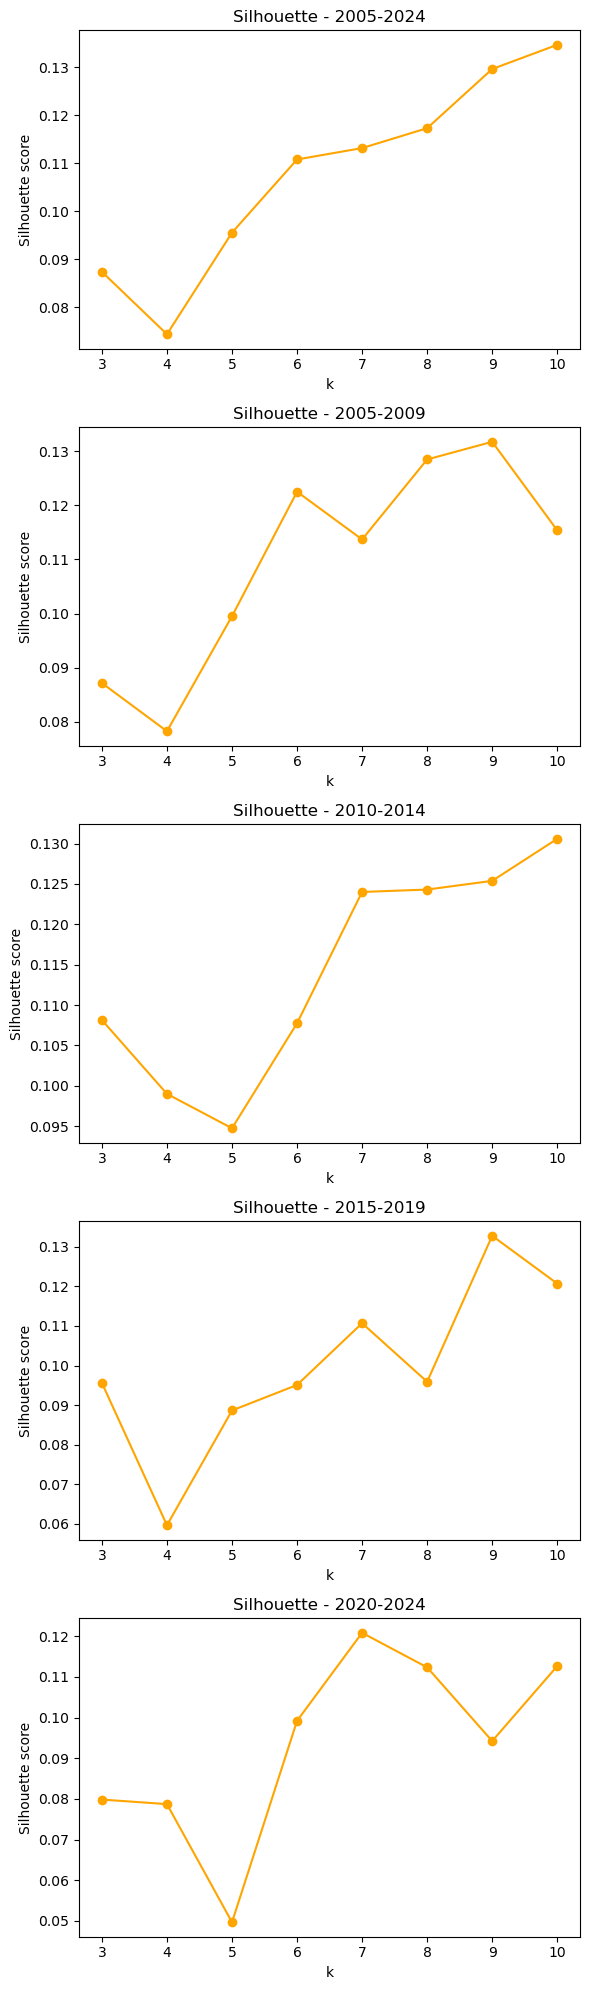

In [106]:
fig, axes = plt.subplots(len(results), 1, figsize=(6, 4 * len(results)))

for i, (name, res) in enumerate(results.items()):
    axes[i].plot(res["k"], res["silhouette"], marker="o", color="orange")
    axes[i].set_title(f"Silhouette - {name}")
    axes[i].set_xlabel("k")
    axes[i].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

Choosing number of cluster

In [110]:
final_k = 7

final_models = {}
final_labels = {}

for name, scaled_df in scaled_data.items():
    km = KMeans(n_clusters=final_k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_df.values)
    final_models[name] = km
    final_labels[name] = pd.Series(labels, index=scaled_df.index, name="cluster")

for name in periods:
    print(f"{name}: {final_labels[name].value_counts().sort_index().to_dict()}")

2005-2024: {0: 36, 1: 10, 2: 45, 3: 17, 4: 26, 5: 37, 6: 28}
2005-2009: {0: 34, 1: 15, 2: 42, 3: 19, 4: 33, 5: 35, 6: 21}
2010-2014: {0: 25, 1: 32, 2: 13, 3: 26, 4: 32, 5: 39, 6: 32}
2015-2019: {0: 41, 1: 16, 2: 33, 3: 34, 4: 41, 5: 5, 6: 29}
2020-2024: {0: 27, 1: 60, 2: 44, 3: 29, 4: 26, 5: 8, 6: 5}


Labelling

In [126]:
def print_cluster_members(share_df, labels, top_n=10):
    for cluster_id in sorted(labels.unique()):
        countries_in_cluster = labels[labels == cluster_id].index.tolist()
        mean_share = share_df.loc[countries_in_cluster].mean()
        top_crops = mean_share.sort_values(ascending=False).head(top_n)

        print(f"\n=== Cluster {cluster_id} ({len(countries_in_cluster)} countries) ===")
        print("Countries:", ", ".join(sorted(countries_in_cluster)))
        print("Top crops:")
        for crop, pct in top_crops.items():
            print(f"  {crop}: {pct:.2f}%")

period = "2005-2024"
print_cluster_members(shares[period], aligned_labels[period])


=== Cluster 0 (45 countries) ===
Countries: Austria, Bangladesh, Belarus, Belgium, Bosnia and Herzegovina, Bulgaria, Canada, Croatia, Czechia, Denmark, Eritrea, Estonia, Ethiopia, Faroe Islands, Finland, France, Germany, Hungary, Iceland, Ireland, Kazakhstan, Kyrgyzstan, Latvia, Lesotho, Lithuania, Luxembourg, Mauritania, Mongolia, Myanmar, Nepal, Netherlands (Kingdom of the), New Zealand, Norway, Poland, Republic of Moldova, Romania, Russian Federation, Serbia, Slovakia, Slovenia, Sweden, Switzerland, Ukraine, United Kingdom of Great Britain and Northern Ireland, United States of America
Top crops:
  Cereals, primary: 29.50%
  Roots and Tubers, Total: 6.33%
  Sugar Crops Primary: 6.15%
  Potatoes: 5.95%
  Sugar beet: 5.46%
  Vegetables Primary: 4.23%
  Fruit Primary: 2.76%
  Oilcrops, Cake Equivalent: 1.60%
  Rape or colza seed: 1.54%
  Other vegetables, fresh n.e.c.: 1.12%

=== Cluster 1 (37 countries) ===
Countries: Argentina, Botswana, Brunei Darussalam, Burkina Faso, Chad, China,

In [121]:
%pip install country_converter

Note: you may need to restart the kernel to use updated packages.


In [127]:
import plotly.express as px
import country_converter as coco   # pip install country_converter

cc = coco.CountryConverter()

# ONE fixed colour per cluster id, reused in every map
_palette = px.colors.qualitative.Set2
CLUSTER_COLORS = {str(c): _palette[c % len(_palette)] for c in range(final_k)}
CLUSTER_ORDER  = [str(c) for c in range(final_k)]

def plot_cluster_map(labels, title):
    df_map = labels.reset_index()
    df_map.columns = ["Area", "Cluster"]
    df_map["Cluster"] = df_map["Cluster"].astype(str)

    # FAO names -> ISO3 so every clustered country actually renders
    df_map["iso3"] = cc.convert(df_map["Area"].tolist(), to="ISO3", not_found=None)
    dropped = df_map.loc[df_map["iso3"].isna(), "Area"].tolist()
    if dropped:
        print(f"[{title}] not placed on map: {dropped}")
    df_map = df_map.dropna(subset=["iso3"])

    fig = px.choropleth(
        df_map,
        locations="iso3",                         # ISO-3, not raw names
        color="Cluster",
        color_discrete_map=CLUSTER_COLORS,        # id -> fixed colour
        category_orders={"Cluster": CLUSTER_ORDER},
        title=title,
    )
    fig.show()

In [128]:
from scipy.optimize import linear_sum_assignment

def get_cluster_centroids(share_df, labels):
    # mean crop-share profile per cluster, in original (unstandardized) % share units —
    # this is the common ground across periods, since each period's StandardScaler was fit separately
    return share_df.groupby(labels).mean()

centroids = {name: get_cluster_centroids(shares[name], final_labels[name]) for name in periods}

reference_period = "2005-2009"
ref_centroids = centroids[reference_period]

aligned_labels = {}

for name in periods:
    if name == reference_period:
        aligned_labels[name] = final_labels[name].copy()
        continue

    cur_centroids = centroids[name]

    cost = np.zeros((final_k, final_k))
    for i in range(final_k):
        for j in range(final_k):
            cost[i, j] = np.linalg.norm(ref_centroids.iloc[i].values - cur_centroids.iloc[j].values)

    ref_idx, cur_idx = linear_sum_assignment(cost)
    mapping = {cur_id: ref_id for ref_id, cur_id in zip(ref_idx, cur_idx)}

    aligned_labels[name] = final_labels[name].map(mapping)

for name in periods:
    print(f"{name}: {aligned_labels[name].value_counts().sort_index().to_dict()}")

2005-2024: {0: 45, 1: 37, 2: 28, 3: 10, 4: 36, 5: 17, 6: 26}
2005-2009: {0: 34, 1: 15, 2: 42, 3: 19, 4: 33, 5: 35, 6: 21}
2010-2014: {0: 32, 1: 26, 2: 32, 3: 13, 4: 39, 5: 32, 6: 25}
2015-2019: {0: 41, 1: 16, 2: 34, 3: 29, 4: 41, 5: 33, 6: 5}
2020-2024: {0: 60, 1: 26, 2: 29, 3: 8, 4: 44, 5: 5, 6: 27}


In [129]:
plot_cluster_map(aligned_labels["2005-2024"], "Country clusters (2005-2024)")
for name in five_year_periods:
    plot_cluster_map(aligned_labels[name], f"Country clusters ({name}) — aligned")

Caribbean not found in regex
Melanesia not found in regex


Caribbean not found in regex
Melanesia not found in regex


Caribbean not found in regex
Melanesia not found in regex


Caribbean not found in regex
Melanesia not found in regex


Caribbean not found in regex
Melanesia not found in regex


In [124]:
transition_rows = []

for i in range(len(five_year_periods) - 1):
    p1 = five_year_periods[i]
    p2 = five_year_periods[i + 1]

    labels1 = aligned_labels[p1]
    labels2 = aligned_labels[p2]

    common_countries = labels1.index.intersection(labels2.index)
    changed = common_countries[labels1.loc[common_countries].values != labels2.loc[common_countries].values]

    for country in changed:
        top_before = shares[p1].loc[country].sort_values(ascending=False).head(3)
        top_after = shares[p2].loc[country].sort_values(ascending=False).head(3)

        transition_rows.append({
            "country": country,
            "period_from": p1,
            "period_to": p2,
            "cluster_from": labels1.loc[country],
            "cluster_to": labels2.loc[country],
            "top_crops_before": ", ".join(f"{c} ({v:.1f}%)" for c, v in top_before.items()),
            "top_crops_after": ", ".join(f"{c} ({v:.1f}%)" for c, v in top_after.items()),
        })

transitions_df = pd.DataFrame(transition_rows)
transitions_df = transitions_df.sort_values(["period_from", "country"])
transitions_df

,country,period_from,period_to,cluster_from,cluster_to,top_crops_before,top_crops_after
0,Argentina,2005-2009,2010-2014,1,0,"Cereals, primary (19.6%), Oilcrops, Cake Equiv...","Cereals, primary (25.0%), Oilcrops, Cake Equiv..."
1,Bahrain,2005-2009,2010-2014,2,3,"Fruit Primary (21.4%), Vegetables Primary (15....","Fruit Primary (18.7%), Vegetables Primary (14...."
2,Burundi,2005-2009,2010-2014,3,6,"Fruit Primary (21.1%), Bananas (19.8%), Roots ...","Roots and Tubers, Total (22.4%), Fruit Primary..."
3,Cabo Verde,2005-2009,2010-2014,2,3,"Vegetables Primary (17.6%), Sugar cane (11.3%)...","Vegetables Primary (17.6%), Sugar cane (10.8%)..."
4,Cambodia,2005-2009,2010-2014,5,6,"Cereals, primary (47.1%), Roots and Tubers, To...","Cereals, primary (32.2%), Roots and Tubers, To..."
...,...,...,...,...,...,...,...
189,United Arab Emirates,2015-2019,2020-2024,5,3,"Fruit Primary (29.3%), Vegetables Primary (16....","Fruit Primary (23.5%), Vegetables Primary (19...."
190,United Republic of Tanzania,2015-2019,2020-2024,3,6,"Roots and Tubers, Total (17.1%), Cereals, prim...","Roots and Tubers, Total (17.3%), Cereals, prim..."
191,Uruguay,2015-2019,2020-2024,1,0,"Cereals, primary (28.0%), Oilcrops, Cake Equiv...","Cereals, primary (31.0%), Oilcrops, Cake Equiv..."
192,Viet Nam,2015-2019,2020-2024,5,4,"Cereals, primary (29.1%), Sugar cane (10.3%), ...","Cereals, primary (28.6%), Vegetables Primary (..."


In [125]:
def explain_transition(row):
    before = shares[row["period_from"]].loc[row["country"]]
    after  = shares[row["period_to"]].loc[row["country"]]
    delta  = after.subtract(before, fill_value=0)   # share-point change per crop
    return pd.Series({
        "biggest_gain": f"{delta.idxmax()} (+{delta.max():.1f} pts)",
        "biggest_drop": f"{delta.idxmin()} ({delta.min():.1f} pts)",
        "mix_shift":    delta.abs().sum() / 2,        # % of portfolio reallocated
    })

detail = transitions_df.apply(explain_transition, axis=1)
transitions_ranked = pd.concat([transitions_df, detail], axis=1) \
                       .sort_values("mix_shift", ascending=False)

transitions_ranked[["country","period_from","period_to",
                    "biggest_gain","biggest_drop","mix_shift"]]

,country,period_from,period_to,biggest_gain,biggest_drop,mix_shift
35,Saint Kitts and Nevis,2005-2009,2010-2014,"Coconuts, in shell (+23.3 pts)",Sugar Crops Primary (-42.3 pts),81.49
43,Trinidad and Tobago,2005-2009,2010-2014,Fruit Primary (+13.1 pts),Sugar Crops Primary (-34.9 pts),54.28
42,Sudan,2005-2009,2010-2014,Sugar Crops Primary (+16.3 pts),Apples (0.0 pts),42.45
101,Sao Tome and Principe,2010-2014,2015-2019,Plantains and cooking bananas (+20.8 pts),Bananas (-16.5 pts),32.42
21,Maldives,2005-2009,2010-2014,Vegetables Primary (+8.2 pts),Bananas (-14.7 pts),26.31
...,...,...,...,...,...,...
142,Equatorial Guinea,2015-2019,2020-2024,Oil palm fruit (+0.3 pts),Sweet potatoes (-0.3 pts),0.49
180,Singapore,2015-2019,2020-2024,Vegetables Primary (+0.4 pts),Tomatoes (-0.0 pts),0.45
137,Congo,2015-2019,2020-2024,"Roots and Tubers, Total (+0.2 pts)",Fruit Primary (-0.1 pts),0.35
57,"China, Macao SAR",2010-2014,2015-2019,Apples (+0.0 pts),Apples (0.0 pts),0.00
